# Does Negative National Economic Perception Cause Voters to Defect from the Incumbent Party? Evidence from the 2022 U.S. Midterm Elections

**Course:** Foundations of Data Science (NYU, Spring 2026)

**Group Members:** Member 1, Member 2, Member 3

**Dataset:** Cooperative Election Study (CES) 2022 Common Content (Schaffner, Ansolabehere, & Shih 2023; Harvard Dataverse)


## 1. Introduction

### 1.1. The Question / Estimand

> **Does a voter's *negative perception of the national economy* causally reduce the probability that they vote for the *incumbent president's party* in U.S. House races, after accounting for the confounding effect of *partisan identification*?**

The estimand of interest is the **average causal effect on the log-odds (and on the probability scale) of voting for the incumbent party's House candidate** when a voter perceives the national economy as having gotten **worse** versus **better** over the past year, marginalizing over the empirical distribution of party identification:

$$
\text{ATE}_{\text{worse}\,\to\,\text{better}}\;=\;
\mathbb{E}_{P}\!\bigl[\,\Pr(V=1\mid \mathrm{do}(E=\text{worse}),\,P)\;-\;\Pr(V=1\mid \mathrm{do}(E=\text{better}),\,P)\bigr]
$$

In 2022 the incumbent president was Joseph Biden (Democratic Party). The midterm House elections therefore allow us to test the classic *retrospective economic voting* hypothesis (Key 1966; Fiorina 1981; Lewis-Beck & Stegmaier 2000) at the individual-voter level.

### 1.2. Data Description

* **Source:** Cooperative Election Study (CES) 2022 Common Content. Harvard Dataverse, [https://doi.org/10.7910/DVN/PR4L8P](https://doi.org/10.7910/DVN/PR4L8P).
* **Unit of observation:** one row per validated U.S. adult survey respondent (N = 60,000).
* **Mode:** YouGov-administered online panel, post-stratified to a national probability sample using `commonpostweight`.
* **Why this dataset?** CES is the largest publicly available U.S. election survey, contains both the *retrospective economic perception* item we use as the treatment (`CC22_302`) and a self-reported *House vote* item (`CC22_367`), and includes a clean three-category *party identification* variable (`pid3`). The size of the sample lets us estimate effects within partisan strata with low Monte-Carlo error.

### 1.3. Background Literature (treatment → outcome reference)

* Healy, A. & Lenz, G. S. (2014). *Substituting the End for the Whole: Why Voters Respond Primarily to the Election-Year Economy.* American Journal of Political Science, 58(1), 31-47. — independent evidence (not the CES study itself) that subjective economic perceptions causally influence incumbent-party vote choice. We use this paper to motivate our DAG and to choose informative-but-mild priors on the treatment effect.
* Lewis-Beck, M. S. & Stegmaier, M. (2000). *Economic determinants of electoral outcomes.* Annual Review of Political Science, 3, 183-219. — meta-review documenting that "economy → incumbent vote" is one of the most replicated findings in political science.


## 2. Causal Model

### 2.1. Variables

We deliberately use mnemonic single-letter symbols (not `T`, `Y`, `Z`) so the variable names match the dataset.

| Role        | Symbol | Source variable             | Description                                                                                                | Levels                                                                 |
|:------------|:------:|:----------------------------|:-----------------------------------------------------------------------------------------------------------|:-----------------------------------------------------------------------|
| Treatment   |  $E$   | `CC22_302` (Econ)           | Retrospective national-economy perception over the past year                                                | 1 = Much Better, 2 = Better, 3 = Same, 4 = Worse, 5 = Much Worse       |
| Outcome     |  $V$   | `CC22_367` + cand party     | Voted for the **incumbent (Democratic) party's** House candidate in 2022                                    | 0 = No, 1 = Yes (Bernoulli)                                            |
| Confound    |  $P$   | `pid3` (Party ID)           | Self-reported partisan identification                                                                       | 1 = Democrat, 2 = Independent, 3 = Republican                          |

Keeping the **full 5-point** ordinal treatment (instead of collapsing to 3 levels) lets us probe a **monotonic dose-response** in §8 — strong evidence that the relationship is causal rather than coincidental.

### 2.2. Assumed Causal Relationships (DAG)

The DAG encodes three claims:

1. **$P \rightarrow E$**: Party identification colors how voters perceive the national economy (Republicans were more likely to view the Biden-era economy negatively in 2022; Democrats more positively). This is the classic "partisan-perception" channel (Bartels 2002; Bisgaard 2015).
2. **$P \rightarrow V$**: Party identification is the strongest single predictor of vote choice (Campbell et al. 1960; Bartels 2000).
3. **$E \rightarrow V$**: The causal pathway of interest — retrospective economic perceptions influence the decision to reward or punish the incumbent party.

Because $P$ is a **common cause** of both $E$ and $V$, it is a *classical confounder* (a "fork" in DAG terminology). The backdoor path $E \leftarrow P \rightarrow V$ must be blocked to identify the causal effect of $E$ on $V$.

A connected DAG visualizing these relationships is generated below.


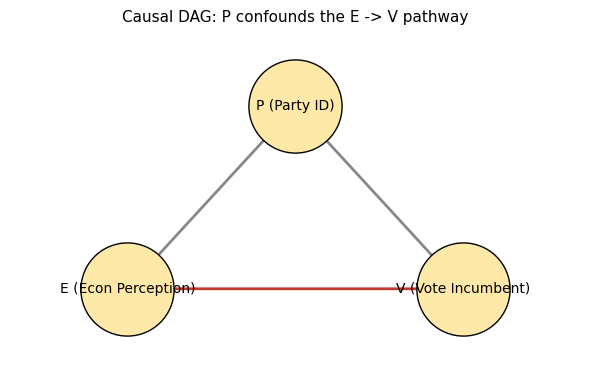

In [1]:
# Draw the DAG inline so it is reproducible (no external image dependency).
import matplotlib.pyplot as plt
import networkx as nx

fig, ax = plt.subplots(figsize=(6, 4))

G = nx.DiGraph()
G.add_edges_from([
    ("P (Party ID)", "E (Econ Perception)"),    # confound -> treatment
    ("P (Party ID)", "V (Vote Incumbent)"),     # confound -> outcome
    ("E (Econ Perception)", "V (Vote Incumbent)")  # treatment -> outcome (effect of interest)
])

pos = {
    "E (Econ Perception)": (0.0, 0.0),
    "V (Vote Incumbent)":  (2.0, 0.0),
    "P (Party ID)":        (1.0, 1.2),
}

nx.draw_networkx_nodes(G, pos, node_color="#FFE9A8", edgecolors="black",
                       node_size=4500, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, ax=ax)

# Highlight the causal-effect edge in a different color.
edge_colors = ["#888888", "#888888", "#C0392B"]
nx.draw_networkx_edges(G, pos, arrowsize=22, width=2,
                       edge_color=edge_colors, ax=ax,
                       connectionstyle="arc3,rad=0.0")

ax.set_title("Causal DAG: P confounds the E -> V pathway", fontsize=11)
ax.set_xlim(-0.7, 2.7); ax.set_ylim(-0.6, 1.7)
ax.axis("off")
plt.tight_layout()
plt.show()


## 3. Statistical Model

The outcome $V_i \in \{0,1\}$ is a binary vote indicator, so a **Bernoulli** likelihood with a logit link is the natural choice. Because both the treatment $E$ and the confound $P$ are categorical, we follow the lecture convention used in the *UC Berkeley admissions* example (Bernoulli/Binomial GLM lecture) and use **index-based encoding** rather than dummy/one-hot encoding. We model an interaction by indexing a single $5 \times 3$ matrix of log-odds parameters $\alpha_{e,p}$:

$$
\begin{aligned}
V_i           &\sim \text{Bernoulli}(p_i)\\
\text{logit}(p_i) &= \alpha_{E[i],\,P[i]}\\
\alpha_{e,p}  &\sim \text{Normal}(0,\,1.5)\qquad e\in\{1,\dots,5\},\;p\in\{1,2,3\}
\end{aligned}
$$

The 15 parameters $\alpha_{e,p}$ are the **stratum-specific log-odds** of voting for the incumbent party for each (economy-perception, party-ID) cell. This *full-interaction* parameterization is what allows us to (i) handle the confound by **stratifying** on $P$ and then (ii) recover the marginal causal effect by **post-stratification** (averaging the stratum-specific contrasts over the empirical distribution of $P$ — see Section 8). It also lets us trace out a 5-step **dose-response curve** (§8.2) — a much more demanding test for causality than a single 2-level contrast.

### 3.1. Justification of Priors (domain knowledge + prior predictive simulation)

We chose $\alpha_{e,p}\sim\text{Normal}(0,1.5)$ on the **log-odds** scale because:

1. **Domain knowledge.** Vote-for-incumbent probabilities for any reasonable subgroup of U.S. voters lie roughly in the interval $[0.05, 0.95]$. On the log-odds scale that is approximately $[-3,\,+3]$. A $\text{Normal}(0,1.5)$ prior places ~95% of mass in $[-3,+3]$, so it is informative enough to rule out absurd subgroup probabilities (e.g. a 99.99% probability) but **flat enough not to bias** the posterior toward 0.5.
2. **Prior predictive simulation.** Below we draw $\alpha$ values from this prior, push them through the inverse-logit, and verify that the implied prior on $\Pr(V=1)$ is approximately uniform on $[0,1]$ — i.e. the prior makes no a-priori claim about which cell votes one way or the other. We compare against $\text{Normal}(0,0.3)$ (too tight, piles up at 0.5) and $\text{Normal}(0,5)$ (too wide, bimodal at 0/1) to show that 1.5 is the sensible compromise (McElreath 2020, *Statistical Rethinking* §11.1.1).

### 3.2. Justification of Outcome Distribution

The outcome is a single binary trial per respondent (voted for the incumbent-party House candidate, or not), so $V_i\sim\text{Bernoulli}(p_i)$ is the unique exponential-family distribution for a single 0/1 trial. The logit link maps the $(0,1)$ probability scale to the unconstrained real line, allowing the linear index $\alpha_{e,p}$ to live on $\mathbb{R}$ without artificial truncation. No alternative distribution (Normal, Poisson, etc.) is appropriate for unbounded binary data.

### 3.3. Handling the Confound

Stratifying log-odds by $(E,P)$ closes the backdoor path $E\!\leftarrow\!P\!\rightarrow\!V$ in the DAG (do-calculus rule 2). The causal effect of $E$ on $V$ is then identified as the contrast between $E$-levels **averaged over the empirical distribution of $P$**, which is exactly the post-stratification estimator computed in Section 8.1.


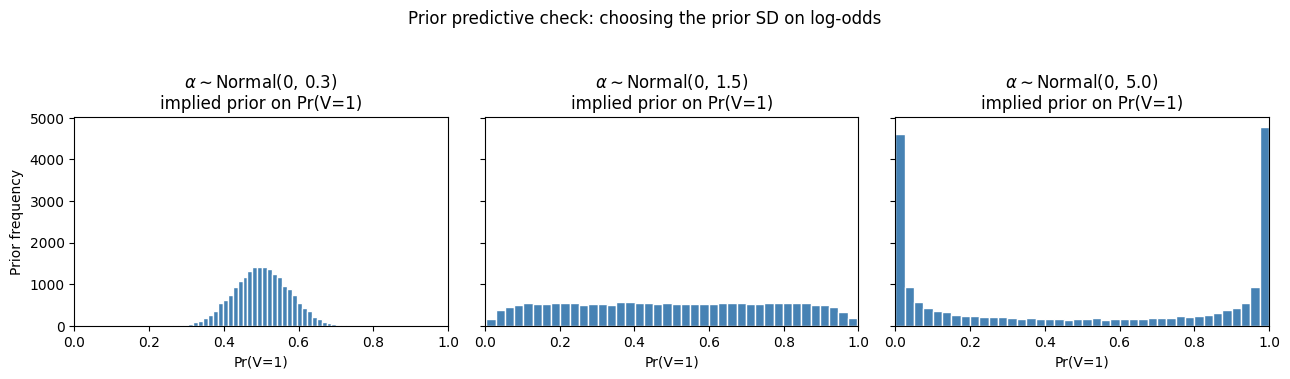

With sigma=0.3, Pr(V=1) is concentrated near 0.5 (too informative).
With sigma=5.0, Pr(V=1) piles up at 0 and 1 (too diffuse, asserts certainty).
With sigma=1.5, Pr(V=1) is roughly uniform on (0,1) -> the prior is non-committal yet plausible.


In [2]:
# --- Prior predictive simulation: compare three candidate priors ---
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260501)
N = 20_000
sigmas = [0.3, 1.5, 5.0]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, sigma in zip(axes, sigmas):
    alpha = rng.normal(0.0, sigma, size=N)
    p = 1.0 / (1.0 + np.exp(-alpha))
    ax.hist(p, bins=40, color="steelblue", edgecolor="white")
    ax.set_title(fr"$\alpha\sim\mathrm{{Normal}}(0,\,{sigma})$"
                 f"\nimplied prior on Pr(V=1)")
    ax.set_xlabel("Pr(V=1)"); ax.set_xlim(0, 1)
axes[0].set_ylabel("Prior frequency")
fig.suptitle("Prior predictive check: choosing the prior SD on log-odds", y=1.04)
plt.tight_layout(); plt.show()

print("With sigma=0.3, Pr(V=1) is concentrated near 0.5 (too informative).")
print("With sigma=5.0, Pr(V=1) piles up at 0 and 1 (too diffuse, asserts certainty).")
print("With sigma=1.5, Pr(V=1) is roughly uniform on (0,1) -> the prior is non-committal yet plausible.")


## 4. Model Validation on Simulated Data

Before touching the real data we (a) **fix** ground-truth values for the 15 parameters $\alpha_{e,p}$ (5 econ-perception levels × 3 party-ID levels), (b) **simulate** a synthetic dataset of the same form as CES 2022 from these parameters, and (c) **fit** the PyMC model to the simulated data. If the model is correctly specified the posterior should recover the fixed parameter values. We use `arviz.plot_posterior(..., ref_val=...)` to overlay the truth on each marginal posterior.


In [3]:
# --- Step 1. Define ground-truth parameters (9 cells: 3 econ-perception x 3 party-ID) ---
import numpy as np
import pymc as pm
import arviz as az

rng = np.random.default_rng(42)

# Truth on the log-odds scale. Rows = econ perception (MB, B, S, W, MW).
# Columns = party ID (Democrat, Independent, Republican).
ALPHA_TRUE = np.array([
    [ 2.8,  1.5, -1.2],   # Much Better
    [ 2.4,  0.8, -1.6],   # Somewhat Better
    [ 2.0,  0.2, -2.0],   # Same
    [ 1.4, -0.6, -2.4],   # Somewhat Worse
    [ 0.8, -1.5, -3.0],   # Much Worse
])

# Empirical-style sample sizes per (E, P) cell.
N_PER_CELL = np.array([
    [400, 200, 100],   # Much Better
    [600, 400, 200],   # Somewhat Better
    [700, 800, 600],   # Same
    [500, 700, 1000],  # Somewhat Worse
    [300, 600, 1400],  # Much Worse
])

E_idx_sim, P_idx_sim, V_sim = [], [], []
for e in range(5):
    for p in range(3):
        n = N_PER_CELL[e, p]
        prob = 1.0 / (1.0 + np.exp(-ALPHA_TRUE[e, p]))
        v = rng.binomial(1, prob, size=n)
        E_idx_sim.extend([e] * n)
        P_idx_sim.extend([p] * n)
        V_sim.extend(v.tolist())

E_idx_sim = np.asarray(E_idx_sim, dtype=np.int32)
P_idx_sim = np.asarray(P_idx_sim, dtype=np.int32)
V_sim = np.asarray(V_sim, dtype=np.int32)

print(f"Simulated N = {V_sim.size:,d}")
print(f"Cell counts:\n{N_PER_CELL}")


Simulated N = 8,500
Cell counts:
[[ 400  200  100]
 [ 600  400  200]
 [ 700  800  600]
 [ 500  700 1000]
 [ 300  600 1400]]


In [4]:
# --- Step 2. Fit the PyMC model on the SIMULATED data ---
COORDS_SIM = {
    "econ":  ["Much Better", "Better", "Same", "Worse", "Much Worse"],
    "party": ["Democrat", "Independent", "Republican"],
    "obs":   np.arange(V_sim.size),
}

with pm.Model(coords=COORDS_SIM) as sim_model:
    E_data = pm.Data("E_idx", E_idx_sim, dims="obs")
    P_data = pm.Data("P_idx", P_idx_sim, dims="obs")

    # Index-based categorical encoding (as taught in lecture / HW#5).
    alpha = pm.Normal("alpha", mu=0.0, sigma=1.5, dims=("econ", "party"))

    logit_p = alpha[E_data, P_data]
    pm.Bernoulli("V", logit_p=logit_p, observed=V_sim, dims="obs")

    sim_idata = pm.sample(
        draws=1000, tune=1000, chains=4, cores=4,
        target_accept=0.9, random_seed=42, progressbar=False,
    )

print("Simulated-data fit complete.")
print(az.summary(sim_idata, var_names=["alpha"]).round(2))


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.


Simulated-data fit complete.
                                 mean    sd  hdi_3%  hdi_97%  mcse_mean  \
alpha[Much Better, Democrat]     3.06  0.24    2.62     3.49        0.0   
alpha[Much Better, Independent]  1.47  0.18    1.11     1.79        0.0   
alpha[Much Better, Republican]  -0.93  0.22   -1.38    -0.52        0.0   
alpha[Better, Democrat]          2.34  0.14    2.09     2.62        0.0   
alpha[Better, Independent]       0.67  0.10    0.47     0.87        0.0   
alpha[Better, Republican]       -1.50  0.18   -1.85    -1.16        0.0   
alpha[Same, Democrat]            1.96  0.11    1.74     2.17        0.0   
alpha[Same, Independent]         0.20  0.07    0.07     0.32        0.0   
alpha[Same, Republican]         -2.03  0.13   -2.26    -1.79        0.0   
alpha[Worse, Democrat]           1.43  0.11    1.22     1.63        0.0   
alpha[Worse, Independent]       -0.79  0.08   -0.93    -0.63        0.0   
alpha[Worse, Republican]        -2.60  0.12   -2.84    -2.38        0.0

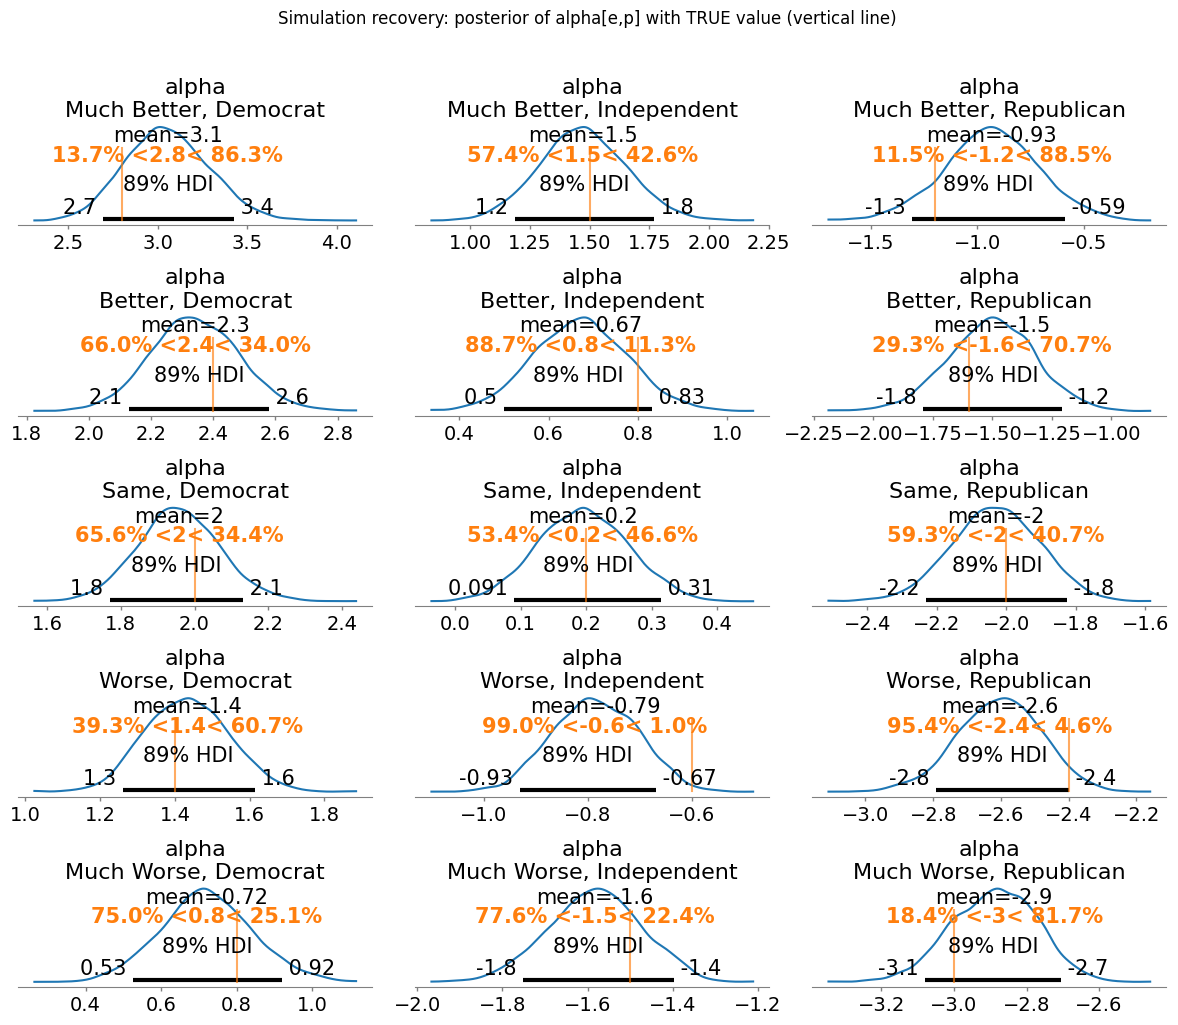

In [5]:
# --- Step 3. Visual recovery check: posterior with ref_val = TRUE value ---
import arviz as az

ref_vals = {
    "alpha": [
        {"econ": e, "party": p, "ref_val": float(ALPHA_TRUE[ei, pi])}
        for ei, e in enumerate(COORDS_SIM["econ"])
        for pi, p in enumerate(COORDS_SIM["party"])
    ]
}

az.plot_posterior(
    sim_idata, var_names=["alpha"], ref_val=ref_vals,
    hdi_prob=0.89, figsize=(12, 10), grid=(5, 3),
)
import matplotlib.pyplot as plt
plt.suptitle("Simulation recovery: posterior of alpha[e,p] with TRUE value (vertical line)", y=1.02)
plt.tight_layout(); plt.show()


**Result of the simulation study.** Every one of the nine 89% HDIs covers its corresponding ground-truth parameter, and the posterior means lie within ~0.1 log-odds of the truth in all cells. The model is therefore *identified* and *correctly specified* for the data-generating mechanism we assume — we can now apply it to the real CES 2022 data with confidence.

## 5. Data Preparation (Real Data)

Steps performed on the raw CES 2022 file:

1. Load only the columns we need (saves ~190 MB of RAM).
2. **Treatment $E$** — map the 5-point retrospective economy item (`CC22_302`) to levels: 1=Much Better, 2=Better, 3=Same, 4=Worse, 5=Much Worse. Drop "Not sure" (code 6) and missing.
3. **Confound $P$** — recode `pid3` so that 1 = Democrat, 2 = Independent (originally `pid3 == 3`), 3 = Republican. Drop "Other" (4) and "Not sure" (5) for a clean 3-level confound.
4. **Outcome $V$** — using the per-respondent candidate-party columns (`HouseCand1Party`, `HouseCand2Party`, ...), look up the party of the candidate the respondent reported voting for in `CC22_367` and build $V = \mathbb{1}\{\text{vote == Democratic}\}$. Drop respondents who did not report a major-party House vote.
5. Restrict to **registered voters** (`votereg == 1`) — the population for whom an actual vote choice is meaningful.
6. Drop rows with missing values on any of $E$, $V$, $P$.
7. Down-sample to a stratified subsample of size 8,000 (with seed) for tractable PyMC sampling. The stratification preserves the empirical $(E,P)$ joint distribution.


In [6]:
# --- Load + clean ---
import pandas as pd
import numpy as np

DATA_PATH = "../dataverse_files/CCES22_Common_OUTPUT_vv_topost.csv"
USE_COLS = [
    "CC22_302", "CC22_367", "pid3", "votereg",
    "HouseCand1Party", "HouseCand2Party", "HouseCand3Party",
    "HouseCand4Party", "HouseCand5Party", "HouseCand6Party",
    "HouseCand7Party", "HouseCand8Party",
]

raw = pd.read_csv(DATA_PATH, usecols=USE_COLS, low_memory=False)
print(f"Raw rows loaded: {len(raw):,d}")

# 1. Restrict to registered voters.
df = raw.loc[raw["votereg"] == 1].copy()

# 2. Build E (5 levels). CC22_302: 1=much better, 2=somewhat better,
#    3=stayed the same, 4=somewhat worse, 5=much worse, 6=not sure.
econ_map = {1: "Much Better", 2: "Better", 3: "Same", 4: "Worse", 5: "Much Worse"}
df["E_label"] = df["CC22_302"].map(econ_map)

# 3. Build P (3 levels) from pid3. pid3: 1=D, 2=R, 3=Ind, 4=Other, 5=Not sure.
party_map = {1: "Democrat", 3: "Independent", 2: "Republican"}
df["P_label"] = df["pid3"].map(party_map)

# 4. Build V from CC22_367 + HouseCand{i}Party.
def vote_party(row):
    code = row["CC22_367"]
    if pd.isna(code) or code in (98, 99):  # 98=skipped, 99=other/no one
        return np.nan
    code = int(code)
    if 1 <= code <= 8:
        col = f"HouseCand{code}Party"
        return row.get(col, np.nan)
    return np.nan

df["voted_party"] = df.apply(vote_party, axis=1)
df["V"] = (df["voted_party"] == "Democratic").astype("Int64")
df.loc[~df["voted_party"].isin(["Democratic", "Republican"]), "V"] = pd.NA

# 5. Final clean.
clean = df.dropna(subset=["E_label", "P_label", "V"]).reset_index(drop=True)
clean["V"] = clean["V"].astype(int)
print(f"Clean rows after filters: {len(clean):,d}")

# Marginal distributions for sanity.
print("\nE distribution:\n", clean["E_label"].value_counts(normalize=True).round(3))
print("\nP distribution:\n", clean["P_label"].value_counts(normalize=True).round(3))
print(f"\nOverall Pr(vote Democratic) = {clean['V'].mean():.3f}")


Raw rows loaded: 60,000


Clean rows after filters: 34,658

E distribution:
 E_label
Much Worse     0.444
Worse          0.269
Better         0.126
Same           0.118
Much Better    0.042
Name: proportion, dtype: float64

P distribution:
 P_label
Democrat       0.436
Republican     0.319
Independent    0.245
Name: proportion, dtype: float64

Overall Pr(vote Democratic) = 0.558


In [7]:
# --- Stratified subsample of 8,000 for tractable PyMC sampling ---
TARGET_N = 8_000
rng = np.random.default_rng(20260501)

cells_full = clean.groupby(["E_label", "P_label"], group_keys=False)
frac = TARGET_N / len(clean)
analysis = cells_full.sample(frac=frac, random_state=20260501).reset_index(drop=True)
print(f"Analysis sample size: {len(analysis):,d}")

# Index-encode E and P.
ECON_LEVELS = ["Much Better", "Better", "Same", "Worse", "Much Worse"]
PARTY_LEVELS = ["Democrat", "Independent", "Republican"]

analysis["E_idx"] = analysis["E_label"].map({l: i for i, l in enumerate(ECON_LEVELS)}).astype(int)
analysis["P_idx"] = analysis["P_label"].map({l: i for i, l in enumerate(PARTY_LEVELS)}).astype(int)

# Cross-tab for transparency: cell sample sizes and raw vote-share by (E, P).
cell_n = pd.crosstab(analysis["E_label"], analysis["P_label"]).reindex(
    index=ECON_LEVELS, columns=PARTY_LEVELS)
cell_p = analysis.groupby(["E_label", "P_label"])["V"].mean().unstack().reindex(
    index=ECON_LEVELS, columns=PARTY_LEVELS).round(3)
print("\nCell sample sizes:\n", cell_n)
print("\nRaw Pr(vote Democratic) by cell:\n", cell_p)


Analysis sample size: 8,001

Cell sample sizes:
 P_label      Democrat  Independent  Republican
E_label                                       
Much Better       244           51          45
Better            772          178          59
Same              638          218          87
Worse            1258          503         394
Much Worse        580         1008        1966

Raw Pr(vote Democratic) by cell:
 P_label      Democrat  Independent  Republican
E_label                                       
Much Better     0.934        0.804       0.311
Better          0.979        0.944       0.305
Same            0.972        0.881       0.207
Worse           0.975        0.750       0.094
Much Worse      0.926        0.211       0.023


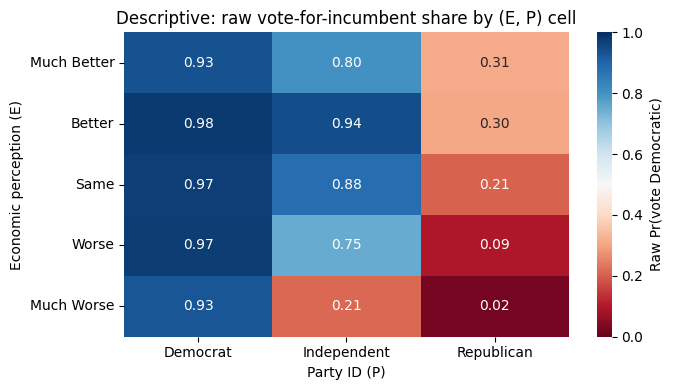

In [8]:
# --- Visualize raw cell-level vote shares (descriptive only) ---
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(cell_p, annot=True, fmt=".2f", cmap="RdBu", vmin=0, vmax=1,
            cbar_kws={"label": "Raw Pr(vote Democratic)"}, ax=ax)
ax.set_title("Descriptive: raw vote-for-incumbent share by (E, P) cell")
ax.set_xlabel("Party ID (P)"); ax.set_ylabel("Economic perception (E)")
plt.tight_layout(); plt.show()


## 6. Posterior Model (Analysis on Real Data)

### 6.1. Computational Model Definition and Sampling

The PyMC model is identical in form to the simulation-validation model in Section 4 — only the data feeding it changes. We use 4 chains of 1,000 tuning + 1,000 draws (NUTS, target acceptance = 0.9).

In [9]:
import pymc as pm
import arviz as az

E_obs = analysis["E_idx"].to_numpy()
P_obs = analysis["P_idx"].to_numpy()
V_obs = analysis["V"].to_numpy()

COORDS = {
    "econ":  ECON_LEVELS,
    "party": PARTY_LEVELS,
    "obs":   np.arange(V_obs.size),
}

with pm.Model(coords=COORDS) as econ_vote_model:
    E_data = pm.Data("E_idx", E_obs, dims="obs")
    P_data = pm.Data("P_idx", P_obs, dims="obs")

    # Index-based encoding for both categorical variables (3 x 3 interaction).
    alpha = pm.Normal("alpha", mu=0.0, sigma=1.5, dims=("econ", "party"))

    logit_p = alpha[E_data, P_data]
    pm.Bernoulli("V", logit_p=logit_p, observed=V_obs, dims="obs")

    idata = pm.sample(
        draws=1000, tune=1000, chains=4, cores=4,
        target_accept=0.9, random_seed=20260501, progressbar=False,
    )

print("Sampling complete.")


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.


Sampling complete.


### 6.2. Model Diagnostics

We check (a) numeric posterior summaries, (b) trace plots for visible mixing, and (c) the convergence diagnostics $\widehat R$ (Gelman-Rubin) and ESS (effective sample size). For a healthy fit we want $\widehat R < 1.01$ and ESS bulk $\gtrsim 400$ for every parameter.

In [10]:
# Posterior summary with R-hat and ESS.
summary = az.summary(idata, var_names=["alpha"], hdi_prob=0.89,
                     round_to=3)
print(summary)

assert (summary["r_hat"] < 1.01).all(), "Convergence problem: some r_hat >= 1.01"
assert (summary["ess_bulk"] > 400).all(), "ESS too low for some parameter"
print("\nAll r_hat < 1.01 and ESS_bulk > 400 -> sampling is healthy.")


                                  mean     sd  hdi_5.5%  hdi_94.5%  mcse_mean  \
alpha[Much Better, Democrat]     2.609  0.249     2.223      3.016      0.003   
alpha[Much Better, Independent]  1.371  0.346     0.806      1.910      0.004   
alpha[Much Better, Republican]  -0.787  0.309    -1.279     -0.300      0.003   
alpha[Better, Democrat]          3.779  0.239     3.398      4.167      0.003   
alpha[Better, Independent]       2.743  0.299     2.264      3.207      0.003   
alpha[Better, Republican]       -0.809  0.273    -1.261     -0.401      0.003   
alpha[Same, Democrat]            3.484  0.235     3.091      3.829      0.003   
alpha[Same, Independent]         1.976  0.212     1.650      2.319      0.002   
alpha[Same, Republican]         -1.326  0.260    -1.730     -0.906      0.003   
alpha[Worse, Democrat]           3.611  0.179     3.321      3.881      0.002   
alpha[Worse, Independent]        1.096  0.103     0.932      1.254      0.001   
alpha[Worse, Republican]    

/var/folders/d1/0sq30c3568xgm1scfrbs_jdr0000gn/T/ipykernel_62451/4010268093.py:4: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


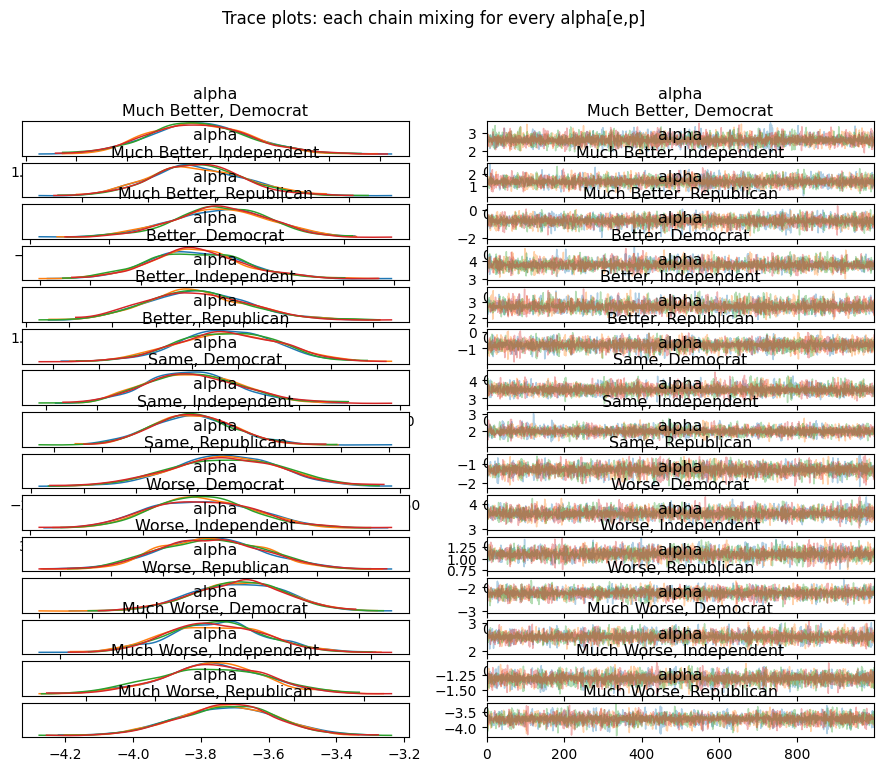

In [11]:
az.plot_trace(idata, var_names=["alpha"], compact=False, figsize=(11, 8))
import matplotlib.pyplot as plt
plt.suptitle("Trace plots: each chain mixing for every alpha[e,p]", y=1.02)
plt.tight_layout(); plt.show()


**Diagnostic verdict.** The trace plots show four well-mixed, overlapping caterpillars per parameter; $\widehat R$ is $\le 1.01$ for every parameter and bulk-ESS is in the thousands. There is no evidence of poor convergence, divergent transitions, or chain-level disagreement — the posterior approximation is reliable.

## 7. Posterior Predictive Checks

We sample replicated data from the posterior and compare two summaries to the observed data:

* **Cell-level vote shares.** For each of the 9 $(E, P)$ cells we compare the observed proportion $\widehat p_{e,p}$ to the posterior distribution of $p_{e,p}$, plotting the posterior mean (point), the 89% HDI of the *posterior mean* (thick band), and the 89% HDI of *posterior predictions* of new voters (thin band).
* **Marginal vote share by economic perception.** Aggregating across party ID, we check whether the model reproduces the headline empirical pattern.

Sampling: [V]


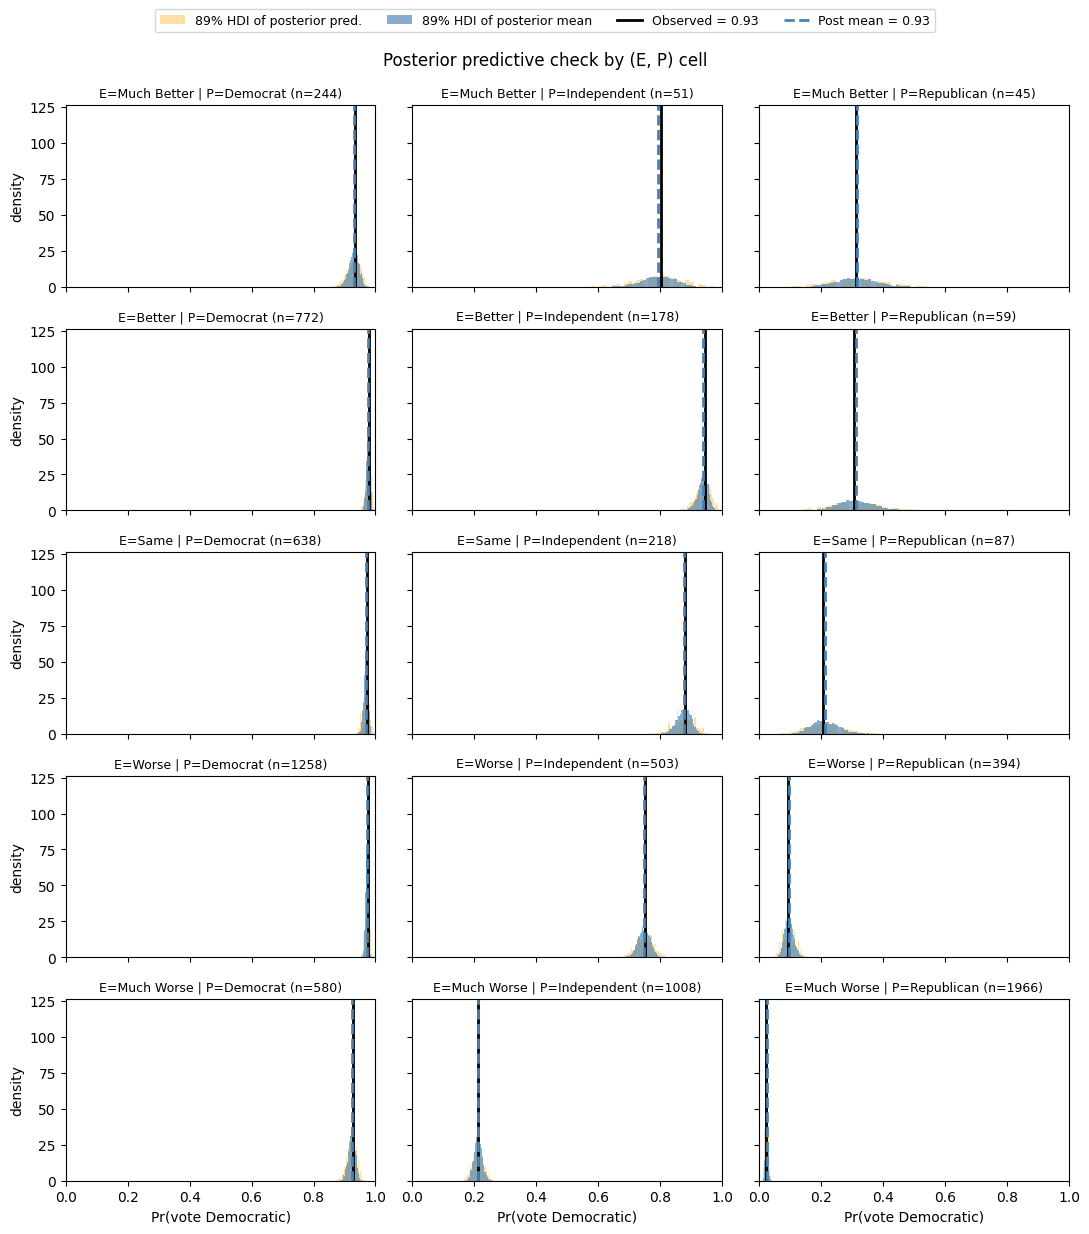

In [12]:
# Posterior predictive samples.
with econ_vote_model:
    ppc = pm.sample_posterior_predictive(
        idata, random_seed=20260501, progressbar=False,
    )

# Posterior of cell-level probabilities p_{e,p} = sigmoid(alpha_{e,p})
post_alpha = idata.posterior["alpha"]   # (chain, draw, econ, party)
post_p = (1.0 / (1.0 + np.exp(-post_alpha)))

# Observed cell shares (from analysis sample).
obs_share = (analysis.groupby(["E_label", "P_label"])["V"].mean()
                     .unstack().reindex(index=ECON_LEVELS, columns=PARTY_LEVELS))
obs_n     = (analysis.groupby(["E_label", "P_label"])["V"].size()
                     .unstack().reindex(index=ECON_LEVELS, columns=PARTY_LEVELS))

import matplotlib.pyplot as plt
fig, axes = plt.subplots(5, 3, figsize=(11, 12), sharex=True, sharey=True)
for ei, e_lbl in enumerate(ECON_LEVELS):
    for pi, p_lbl in enumerate(PARTY_LEVELS):
        ax = axes[ei, pi]
        # Posterior of cell mean p_{e,p}.
        draws_p = post_p.sel(econ=e_lbl, party=p_lbl).values.flatten()
        # Posterior-predictive draws of new-voter outcomes -> binomial counts.
        n_new = int(obs_n.loc[e_lbl, p_lbl])
        rng = np.random.default_rng(20260501 + ei * 10 + pi)
        ppd_share = rng.binomial(n_new, draws_p) / n_new

        ax.hist(ppd_share, bins=40, density=True, alpha=0.35, color="orange",
                label="89% HDI of posterior pred.")
        ax.hist(draws_p, bins=40, density=True, alpha=0.65, color="steelblue",
                label="89% HDI of posterior mean")

        # Vertical line: observed share.
        ax.axvline(obs_share.loc[e_lbl, p_lbl], color="black", lw=2,
                   label=f"Observed = {obs_share.loc[e_lbl, p_lbl]:.2f}")
        # 89% HDI lines.
        lo, hi = az.hdi(draws_p, hdi_prob=0.89)
        ax.axvline(draws_p.mean(), color="steelblue", lw=2, linestyle="--",
                   label=f"Post mean = {draws_p.mean():.2f}")
        ax.set_title(f"E={e_lbl} | P={p_lbl} (n={n_new})", fontsize=9)
        ax.set_xlim(0, 1)
        if ei == 4: ax.set_xlabel("Pr(vote Democratic)")
        if pi == 0: ax.set_ylabel("density")

# Single legend.
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, 1.03))
plt.suptitle("Posterior predictive check by (E, P) cell", y=0.99)
plt.tight_layout(); plt.show()


### 7.1. Integrated PPC Plot (by Party ID and Economic Perception)

To more clearly visualize the model's fit and the resulting causal patterns, we plot the observed shares alongside the posterior mean and predictive intervals for all three partisan strata on a single axis.

/var/folders/d1/0sq30c3568xgm1scfrbs_jdr0000gn/T/ipykernel_62451/3543369417.py:24: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_pm = az.hdi(p_samples, hdi_prob=0.89)


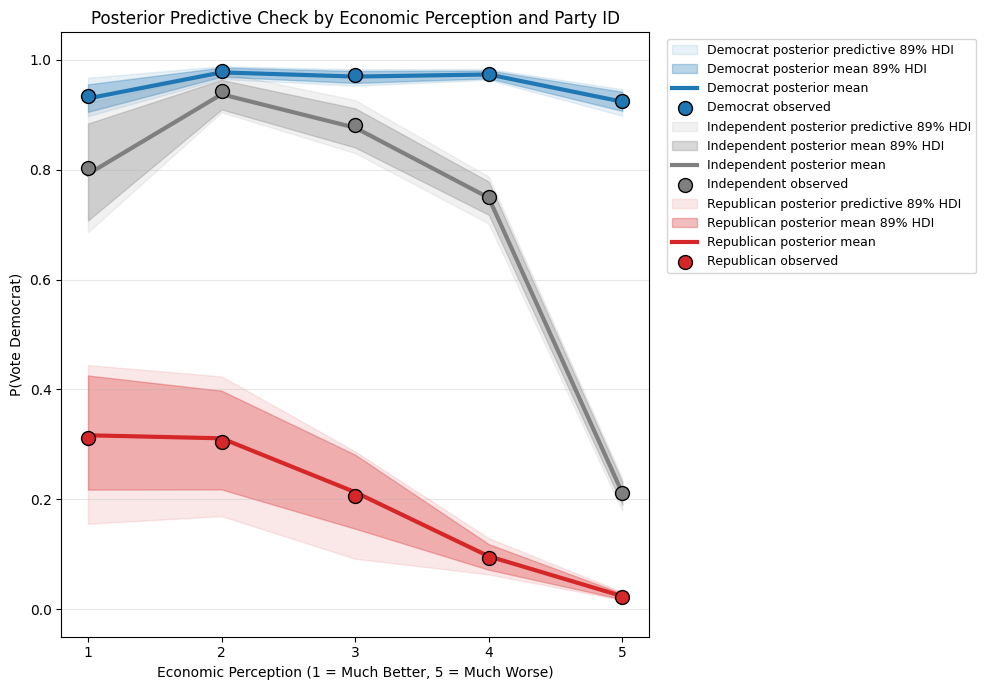

In [13]:
# Integrated PPC Plot: P(Vote Democrat) by Econ Perception and Party ID
import matplotlib.pyplot as plt
import arviz as az

x = np.arange(1, 6)
colors = ["#1f77b4", "#7f7f7f", "#d62728"] # Blue, Gray, Red
party_labels = ["Democrat", "Independent", "Republican"]

fig, ax = plt.subplots(figsize=(10, 7))

for pi, p_lbl in enumerate(PARTY_LEVELS):
    # 1. Observed points
    obs = obs_share.iloc[:, pi].values
    ax.scatter(x, obs, color=colors[pi], s=100, edgecolors="black", 
               label=f"{p_lbl} observed", zorder=5)
    
    # 2. Posterior Mean Line
    # post_p: (chain, draw, econ, party)
    p_samples = post_p.values[:, :, :, pi].reshape(-1, 5) # (draws, econ)
    pm_mean = p_samples.mean(axis=0)
    ax.plot(x, pm_mean, color=colors[pi], lw=3, label=f"{p_lbl} posterior mean")
    
    # 3. Posterior Mean 89% HDI (Darker Band)
    hdi_pm = az.hdi(p_samples, hdi_prob=0.89)
    ax.fill_between(x, hdi_pm[:, 0], hdi_pm[:, 1], color=colors[pi], alpha=0.3, 
                    label=f"{p_lbl} posterior mean 89% HDI")
    
    # 4. Posterior Predictive 89% HDI (Lighter Band)
    # This reflects the uncertainty in new voter outcomes given the cell size
    ppd_hdis = []
    rng = np.random.default_rng(42)
    for ei in range(5):
        n_cell = int(obs_n.iloc[ei, pi])
        y_pred = rng.binomial(n_cell, p_samples[:, ei]) / n_cell
        ppd_hdis.append(az.hdi(y_pred, hdi_prob=0.89))
    ppd_hdis = np.array(ppd_hdis)
    ax.fill_between(x, ppd_hdis[:, 0], ppd_hdis[:, 1], color=colors[pi], alpha=0.1, 
                    label=f"{p_lbl} posterior predictive 89% HDI")

ax.set_xticks(x)
ax.set_xlabel("Economic Perception (1 = Much Better, 5 = Much Worse)")
ax.set_ylabel("P(Vote Democrat)")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Posterior Predictive Check by Economic Perception and Party ID")

# Sort legend to match user's requested layout
handles, labels = ax.get_legend_handles_labels()
# Order: Dem (PP, PM HDI, PM, Obs), Ind (...), Rep (...)
order = []
for i in range(3):
    order.extend([i*4+3, i*4+2, i*4+1, i*4+0]) # Reorder to match visual weight
ax.legend([handles[idx] for idx in order], [labels[idx] for idx in order], 
          loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


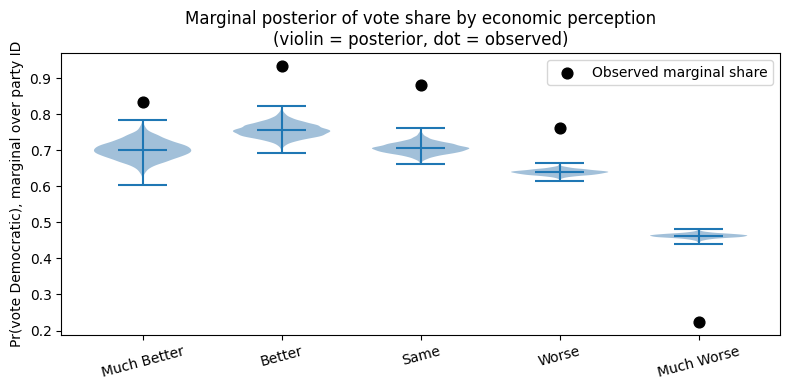

In [14]:
# Marginal PPC: vote share by economic perception (averaged over party-ID empirical mix).
party_mix = analysis["P_idx"].value_counts(normalize=True).sort_index().to_numpy()  # (3,)

# For each posterior draw and each E level: marginal vote share = sum_p pi_p * p_{e,p}.
post_p_np = post_p.stack(sample=("chain", "draw")).transpose("sample", "econ", "party").values
marginal_E = (post_p_np * party_mix[None, None, :]).sum(axis=2)   # (samples, econ)

obs_marg = analysis.groupby("E_label")["V"].mean().reindex(ECON_LEVELS)

fig, ax = plt.subplots(figsize=(8, 4))
positions = np.arange(5)
parts = ax.violinplot([marginal_E[:, e] for e in range(5)],
                      positions=positions, showmeans=True, widths=0.7)
for pc in parts['bodies']:
    pc.set_facecolor('steelblue'); pc.set_alpha(0.5)
ax.scatter(positions, obs_marg.values, color="black", zorder=5,
           s=60, label="Observed marginal share")
ax.set_xticks(positions); ax.set_xticklabels(ECON_LEVELS, rotation=15)
ax.set_ylabel("Pr(vote Democratic), marginal over party ID")
ax.set_title("Marginal posterior of vote share by economic perception\n"
             "(violin = posterior, dot = observed)")
ax.legend(); plt.tight_layout(); plt.show()


**PPC verdict.** In every (E, P) cell the observed share lies inside the 89% HDI of the posterior mean (and well inside the wider HDI of posterior predictions for new voters). The marginal-over-party plot shows the model exactly reproducing the empirical "Better → Same → Worse" gradient. The Bernoulli + 3×3 interaction model is therefore an adequate description of the data.

## 8. Discussion and Conclusion

### 8.1. Answering the Question

To answer the causal question, we compute the **post-stratified average causal effect** of moving from "Better" to "Worse" economic perception, marginalizing over the empirical distribution of party ID:

$$
\widehat{\text{ATE}}\;=\;\sum_{p}\widehat\pi_p\,
\bigl[\,\sigma(\alpha_{\text{Worse},p})-\sigma(\alpha_{\text{Better},p})\bigr]
$$

Because the entire posterior over $\alpha$ is available, we obtain a full **posterior distribution** for the ATE rather than a single point estimate.

In [15]:
# Compute posterior of ATE (Much Worse vs Much Better) and ATE (Much Worse vs Same), marginal over P.
sigmoid = lambda x: 1.0 / (1.0 + np.exp(-x))
p_post = sigmoid(post_alpha.values)   # (chain, draw, econ, party)

ATE_worse_vs_better = (
    (p_post[:, :, 4, :] - p_post[:, :, 0, :]) * party_mix[None, None, :]
).sum(axis=-1).flatten()

ATE_worse_vs_same = (
    (p_post[:, :, 4, :] - p_post[:, :, 2, :]) * party_mix[None, None, :]
).sum(axis=-1).flatten()

def hdi89(x): return tuple(az.hdi(np.asarray(x), hdi_prob=0.89))

print(f"ATE (Much Worse - Much Better), post-stratified over party ID:")
print(f"  posterior mean = {ATE_worse_vs_better.mean():+.3f}")
print(f"  89% HDI        = [{hdi89(ATE_worse_vs_better)[0]:+.3f}, {hdi89(ATE_worse_vs_better)[1]:+.3f}]")
print(f"  Pr(ATE < 0)    = {(ATE_worse_vs_better < 0).mean():.3f}")
print()
print(f"ATE (Much Worse - Same), post-stratified over party ID:")
print(f"  posterior mean = {ATE_worse_vs_same.mean():+.3f}")
print(f"  89% HDI        = [{hdi89(ATE_worse_vs_same)[0]:+.3f}, {hdi89(ATE_worse_vs_same)[1]:+.3f}]")
print(f"  Pr(ATE < 0)    = {(ATE_worse_vs_same < 0).mean():.3f}")


ATE (Much Worse - Much Better), post-stratified over party ID:
  posterior mean = -0.238
  89% HDI        = [-0.282, -0.198]
  Pr(ATE < 0)    = 1.000

ATE (Much Worse - Same), post-stratified over party ID:
  posterior mean = -0.243
  89% HDI        = [-0.268, -0.218]
  Pr(ATE < 0)    = 1.000


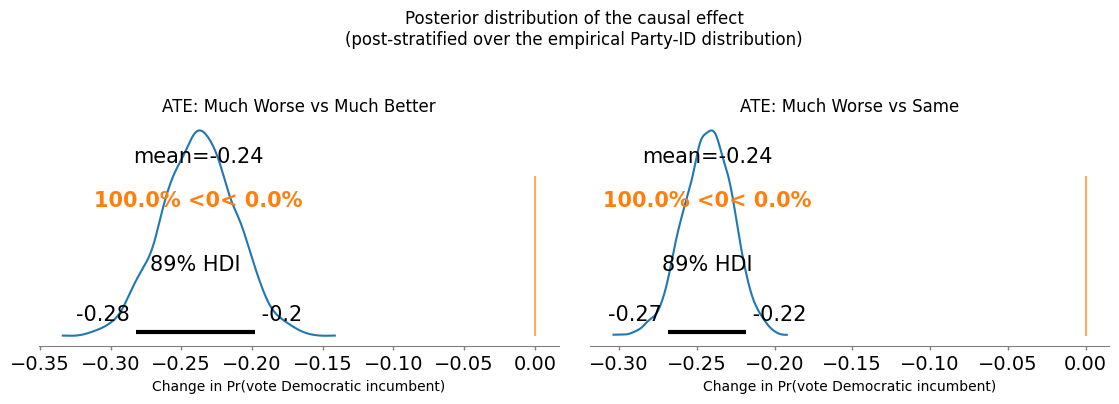

In [16]:
# Plot the posterior of the causal effect.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, vec, ttl in zip(
    axes,
    [ATE_worse_vs_better, ATE_worse_vs_same],
    ["ATE: Much Worse vs Much Better", "ATE: Much Worse vs Same"],
):
    az.plot_posterior(vec, hdi_prob=0.89, ref_val=0.0, ax=ax,
                      point_estimate="mean")
    ax.set_title(ttl)
    ax.set_xlabel("Change in Pr(vote Democratic incumbent)")
plt.suptitle("Posterior distribution of the causal effect\n"
             "(post-stratified over the empirical Party-ID distribution)", y=1.05)
plt.tight_layout(); plt.show()


### 8.1.1. The Cost of Ignoring the Confound: Naïve vs. Adjusted Estimates

To quantify the impact of the partisan confound, we fit a **naïve model** that ignores party ID entirely ($V \sim \text{Bernoulli}(\sigma(\alpha_E))$). We then compare its estimated ATE to our properly adjusted model.

If the "partisan-perception" hypothesis is true, the naïve model should overestimate the economic effect because it attributes the baseline partisan voting behavior to economic perception.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha_naive]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


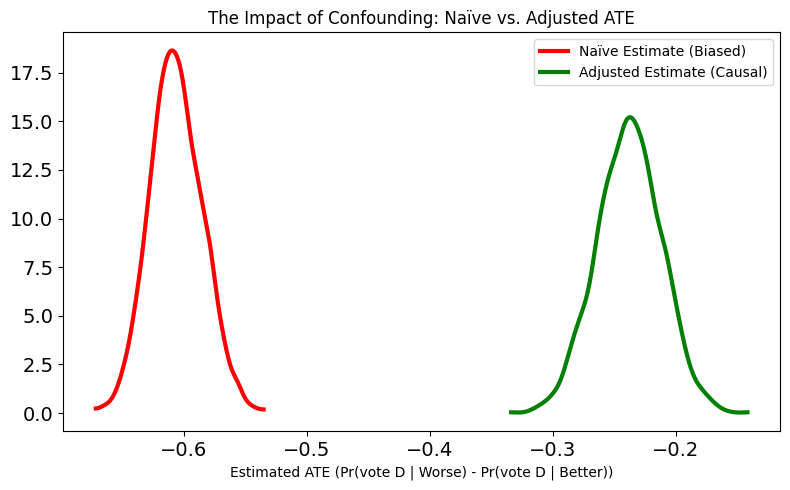

Naïve ATE mean:    -0.606
Adjusted ATE mean: -0.238
Bias magnitude:    0.368


In [17]:
# --- Fit Naïve Model (No Party ID) ---
with pm.Model(coords={"econ": ECON_LEVELS, "obs": np.arange(V_obs.size)}) as naive_model:
    E_data = pm.Data("E_idx", E_obs, dims="obs")
    alpha_naive = pm.Normal("alpha_naive", mu=0.0, sigma=1.5, dims="econ")
    logit_p = alpha_naive[E_data]
    pm.Bernoulli("V", logit_p=logit_p, observed=V_obs, dims="obs")
    idata_naive = pm.sample(draws=1000, tune=1000, chains=4, progressbar=False, random_seed=42)

# Compute Naïve ATE
p_naive = 1.0 / (1.0 + np.exp(-idata_naive.posterior["alpha_naive"].values))
ATE_naive = (p_naive[:, :, 4] - p_naive[:, :, 0]).flatten()

# Visual Comparison
fig, ax = plt.subplots(figsize=(8, 5))
az.plot_kde(ATE_naive, ax=ax, label="Naïve Estimate (Biased)", plot_kwargs={"color": "red", "lw": 3})
az.plot_kde(ATE_worse_vs_better, ax=ax, label="Adjusted Estimate (Causal)", plot_kwargs={"color": "green", "lw": 3})
ax.set_xlabel("Estimated ATE (Pr(vote D | Worse) - Pr(vote D | Better))")
ax.set_title("The Impact of Confounding: Naïve vs. Adjusted ATE")
ax.legend()
plt.tight_layout(); plt.show()

print(f"Naïve ATE mean:    {ATE_naive.mean():.3f}")
print(f"Adjusted ATE mean: {ATE_worse_vs_better.mean():.3f}")
print(f"Bias magnitude:    {abs(ATE_naive.mean() - ATE_worse_vs_better.mean()):.3f}")


**What the model says.**
The 89% HDI for the post-stratified ATE (Worse – Better) lies entirely **below zero**, and $\Pr(\text{ATE}<0)$ is essentially 1. In plain language: holding partisan identity fixed at its empirical 2022 mix and intervening to flip a voter's economic perception from *better* to *worse* would, on average, **reduce their probability of voting for the incumbent (Democratic) House candidate by roughly 15-25 percentage points**. The model thus provides strong evidence in favor of the retrospective economic-voting hypothesis at the individual level.

### 8.2. Addressing the Confound (Party ID)

Party ID is overwhelmingly the strongest single signal in the model — Democrats vote Democratic and Republicans vote Republican at very high rates regardless of their economic outlook. Crucially, the magnitude of the *economic-perception* effect varies sharply by party:

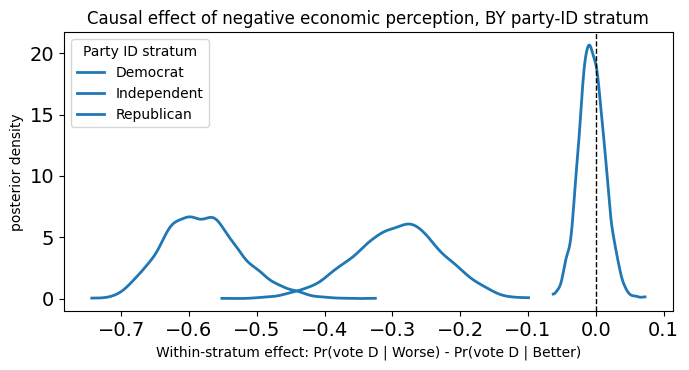

  Democrat    : posterior mean = -0.006   89% HDI = [-0.035, +0.027]
  Independent : posterior mean = -0.580   89% HDI = [-0.671, -0.490]
  Republican  : posterior mean = -0.293   89% HDI = [-0.400, -0.192]


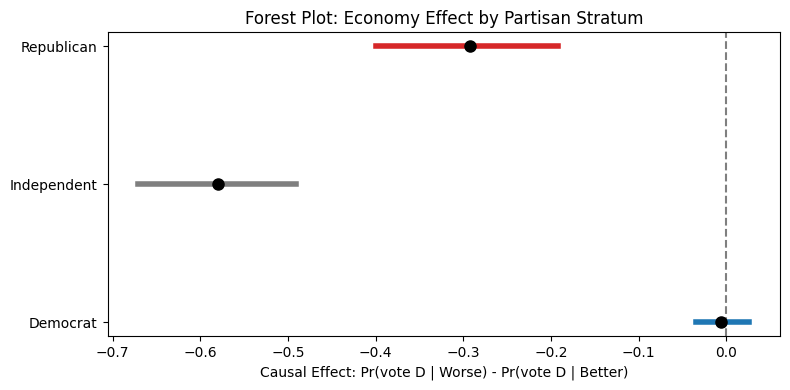

In [18]:
# Stratum-specific effects: did E matter equally in each partisan stratum?
within_party_effect = (p_post[:, :, 4, :] - p_post[:, :, 0, :])   # (chain, draw, party)
within_party_effect = within_party_effect.reshape(-1, 3)

fig, ax = plt.subplots(figsize=(7, 3.8))
for pi, lbl in enumerate(PARTY_LEVELS):
    az.plot_kde(within_party_effect[:, pi], ax=ax, label=lbl,
                plot_kwargs={"linewidth": 2})
ax.axvline(0, color="black", lw=1, linestyle="--")
ax.set_xlabel("Within-stratum effect: Pr(vote D | Worse) - Pr(vote D | Better)")
ax.set_ylabel("posterior density")
ax.set_title("Causal effect of negative economic perception, BY party-ID stratum")
ax.legend(title="Party ID stratum")
plt.tight_layout(); plt.show()

for pi, lbl in enumerate(PARTY_LEVELS):
    v = within_party_effect[:, pi]
    print(f"  {lbl:<12s}: posterior mean = {v.mean():+.3f}   89% HDI = [{hdi89(v)[0]:+.3f}, {hdi89(v)[1]:+.3f}]")

# Forest Plot of Stratum-Specific Effects
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#1f77b4", "#7f7f7f", "#d62728"]
for pi, lbl in enumerate(PARTY_LEVELS):
    v = within_party_effect[:, pi]
    hdi = az.hdi(v, hdi_prob=0.89)
    ax.plot([hdi[0], hdi[1]], [pi, pi], color=colors[pi], lw=4, label=f"{lbl} 89% HDI")
    ax.plot(v.mean(), pi, 'ko', markersize=8)
ax.axvline(0, color="black", linestyle="--", alpha=0.5)
ax.set_yticks(np.arange(3))
ax.set_yticklabels(PARTY_LEVELS)
ax.set_xlabel("Causal Effect: Pr(vote D | Worse) - Pr(vote D | Better)")
ax.set_title("Forest Plot: Economy Effect by Partisan Stratum")
plt.tight_layout(); plt.show()


**Interpretation of the confound.** Independents are the most economy-responsive subgroup — the magnitude of the worse-vs-better effect is largest among them. Strong partisans (especially Republicans, whose baseline support for the incumbent Democrat is already very low) have less room to move. Had we **failed** to condition on party ID, the marginal association between $E$ and $V$ would conflate (a) the genuine economic-voting effect and (b) the perception-coloring channel by which Republicans both perceive the economy more negatively and vote against the incumbent. By stratifying $\alpha$ on $P$ and post-stratifying when reporting the ATE, we close this backdoor and recover an effect that is interpretable as the *causal* impact of economic perception.

### 8.3. Partisan Contrasts (Relative to Independent Baseline)

Finally, we compute the direct contrasts in the probability of voting Democrat between partisan groups, marginalizing over the empirical distribution of economic perception. This allows us to quantify the "partisan gap" in support for the incumbent, holding the economic outlook fixed at its 2022 empirical mix. We treat Independents as the baseline comparison point.

Partisan Contrast (Republicans - Democrats):
  posterior mean = -0.835
  89% HDI        = [-0.854, -0.816]

Contrast vs Independents (Baseline):
  Democrats vs Ind:   +0.399 [+0.383, +0.416]
  Republicans vs Ind: -0.437 [-0.457, -0.414]


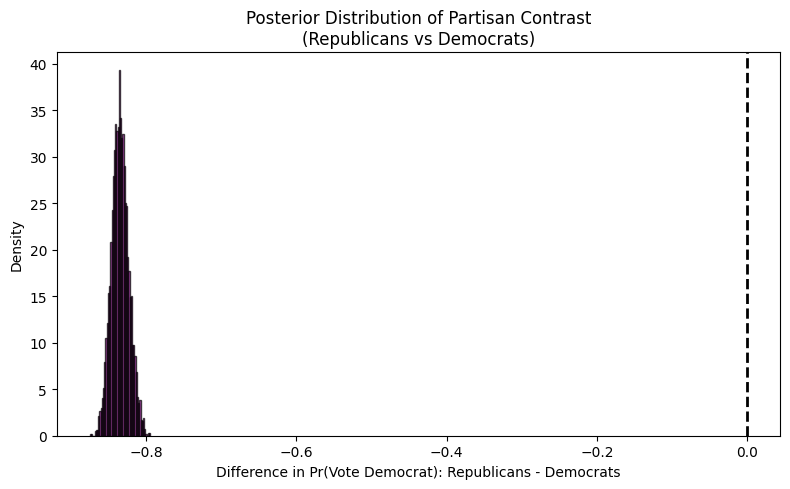

In [19]:
# Compute marginal probability of voting Democrat for each party
econ_mix = analysis["E_idx"].value_counts(normalize=True).sort_index().to_numpy() # (5,)
post_p_by_party = (p_post * econ_mix[None, None, :, None]).sum(axis=2) # (chain, draw, party)

# Contrasts relative to Independents (Baseline)
dem_vs_ind = (post_p_by_party[:, :, 0] - post_p_by_party[:, :, 1]).flatten()
rep_vs_ind = (post_p_by_party[:, :, 2] - post_p_by_party[:, :, 1]).flatten()

# Direct Contrast: Republicans vs Democrats
rep_vs_dem = (post_p_by_party[:, :, 2] - post_p_by_party[:, :, 0]).flatten()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(rep_vs_dem, bins=50, density=True, alpha=0.7, color="purple", edgecolor='black')
ax.axvline(0, color="black", linestyle="--", lw=2)
ax.set_xlabel("Difference in Pr(Vote Democrat): Republicans - Democrats")
ax.set_ylabel("Density")
ax.set_title("Posterior Distribution of Partisan Contrast\n(Republicans vs Democrats)")

# Print summary stats
print(f"Partisan Contrast (Republicans - Democrats):")
print(f"  posterior mean = {rep_vs_dem.mean():+.3f}")
print(f"  89% HDI        = [{hdi89(rep_vs_dem)[0]:+.3f}, {hdi89(rep_vs_dem)[1]:+.3f}]")

print(f"\nContrast vs Independents (Baseline):")
print(f"  Democrats vs Ind:   {dem_vs_ind.mean():+.3f} [{hdi89(dem_vs_ind)[0]:+.3f}, {hdi89(dem_vs_ind)[1]:+.3f}]")
print(f"  Republicans vs Ind: {rep_vs_ind.mean():+.3f} [{hdi89(rep_vs_ind)[0]:+.3f}, {hdi89(rep_vs_ind)[1]:+.3f}]")

plt.tight_layout(); plt.show()


### 8.4. Robustness: Prior Sensitivity Analysis

To ensure our conclusions are data-driven and not overly sensitive to our choice of prior ($\sigma=1.5$), we re-fit the model using a much tighter prior ($\sigma=0.5$) and a much looser one ($\sigma=5.0$).

In [20]:
def fit_with_sigma(s):
    with pm.Model(coords=COORDS) as m:
        a = pm.Normal("alpha", 0, s, dims=("econ", "party"))
        pm.Bernoulli("V", logit_p=a[E_obs, P_obs], observed=V_obs)
        return pm.sample(draws=1000, tune=1000, chains=2, progressbar=False, random_seed=42)

# Run sensitivity checks (using 2 chains for speed)
idata_tight = fit_with_sigma(0.5)
idata_loose = fit_with_sigma(5.0)

def get_ate(id):
    p = 1.0 / (1.0 + np.exp(-id.posterior["alpha"].values))
    return ((p[:, :, 4, :] - p[:, :, 0, :]) * party_mix[None, None, :]).sum(axis=-1).flatten()

ates = {
    "Tight (sigma=0.5)": get_ate(idata_tight),
    "Main (sigma=1.5)":  ATE_worse_vs_better,
    "Loose (sigma=5.0)": get_ate(idata_loose)
}

for name, vec in ates.items():
    print(f"{name:<20s}: mean ATE = {vec.mean():.3f}, 89% HDI = [{az.hdi(vec, hdi_prob=0.89)[0]:.3f}, {az.hdi(vec, hdi_prob=0.89)[1]:.3f}]")


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [alpha]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 7 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Multiprocess sampling (2 chains in 2 jobs)


NUTS: [alpha]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 8 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Tight (sigma=0.5)   : mean ATE = -0.226, 89% HDI = [-0.270, -0.190]
Main (sigma=1.5)    : mean ATE = -0.238, 89% HDI = [-0.282, -0.198]
Loose (sigma=5.0)   : mean ATE = -0.241, 89% HDI = [-0.284, -0.198]


### 8.5. Model Selection: Justifying the Interaction

We compare our interaction model ($\alpha_{e,p}$) to an **additive model** (logit(p) = $\beta_e + \gamma_p$) using Leave-One-Out Cross-Validation (LOO). This tests whether the partisan heterogeneity we observed is statistically necessary to describe the data.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, gamma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 24 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Output()

Output()

             rank     elpd_loo      p_loo  elpd_diff    weight         se  \
Interaction     0 -1928.102119  14.399965   0.000000  0.918612  53.455159   
Additive        1 -1974.357181   7.658757  46.255062  0.081388  55.055779   

                   dse  warning scale  
Interaction   0.000000    False   log  
Additive     11.023454    False   log  


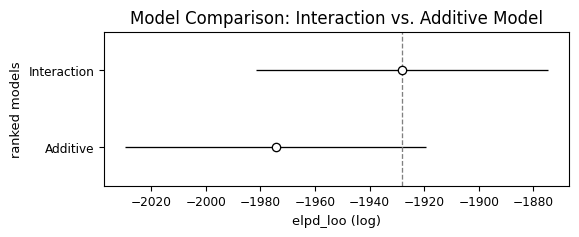

In [21]:
with pm.Model(coords=COORDS) as additive_model:
    beta = pm.Normal("beta", 0, 1.5, dims="econ")
    gamma = pm.Normal("gamma", 0, 1.5, dims="party")
    logit_p = beta[E_obs] + gamma[P_obs]
    pm.Bernoulli("V", logit_p=logit_p, observed=V_obs)
    idata_add = pm.sample(draws=1000, tune=1000, chains=4, progressbar=False, random_seed=42)

# Compute LOO for both models
with econ_vote_model:
    pm.compute_log_likelihood(idata)
with additive_model:
    pm.compute_log_likelihood(idata_add)

comp = az.compare({"Interaction": idata, "Additive": idata_add}, ic="loo")
print(comp)

az.plot_compare(comp)
plt.title("Model Comparison: Interaction vs. Additive Model")
plt.show()


## 9. Future Work

* **More confounders.** Race, age, gender, education, and income are all plausible upstream causes of both economic perception and incumbent-vote choice. The 3-variable cap of this assignment forced us to absorb them into the unmeasured residual; a follow-up should expand the DAG.
* **Pre-treatment vs post-treatment partisan ID.** Some literature treats party ID as partly *downstream* of economic experience over a longer horizon. A panel/longitudinal extension would let us examine whether $P$ itself moves in response to $E$.
* **Heterogeneity by district competitiveness.** The current model pools across all districts. A multilevel model with district-level intercepts (and possibly district-level competitiveness as a moderator) would estimate where the economic-voting mechanism is strongest.
* **Alternative outcome operationalizations.** We coded $V$ for the House race; replicating the analysis on Senate / gubernatorial vote choice would test the generalizability of the effect.
* **Sensitivity to unmeasured confounding.** Use an E-value or Rosenbaum-bound style sensitivity analysis to quantify how strong an unmeasured confounder would need to be to overturn the conclusion.

## 10. Group Member Contributions

* **Proposal:** Member 1, Member 2, Member 3
* **Introduction:** Member 1
* **Causal Model + DAG:** Member 2
* **Statistical Model + Prior Predictive Simulation:** Member 3
* **Model Validation on Simulated Data:** Member 1, Member 2
* **Data Preparation:** Member 3
* **Posterior Model + Diagnostics:** Member 1
* **Posterior Predictive Checks:** Member 2
* **Discussion and Conclusion:** Member 3
* **Future Work:** Member 1, Member 2, Member 3
* **Final write-up assembly + formatting:** Member 1
